# Model_Training.ipynb — Accident Severity Prediction (Multi-Model Comparison)

Using `cleaned_accidents.csv`. Note: `festival` and `date`/`time` (and therefore the
`month` seasonality feature) are no longer available post-cleaning, so this version
trains on the remaining 19 features. We still compare 4 models on macro F1 and
fatal-class recall before picking and saving the best one.

## 1. Imports & Load

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
import joblib

df = pd.read_csv('data/cleaned_accidents.csv')


## 2. Feature Engineering

- `is_night` flag (10 PM–5 AM) derived from `hour` — still possible without `date`.
- No `month` feature this time (no `date` column in the cleaned data).
- Categorical columns label-encoded; encoders saved for reuse at inference time.

In [5]:
df['is_night'] = df['hour'].apply(lambda h: 1 if (h >= 20 or h <= 5) else 0)

cat_cols = ['city','state','road_type','weather','visibility',
            'traffic_density','cause','day_of_week']

encoders = {}
df_enc = df.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    encoders[col] = le

target_le = LabelEncoder()
df_enc['accident_severity_enc'] = target_le.fit_transform(df_enc['accident_severity'])

df_enc[['is_night'] + cat_cols + ['accident_severity_enc']].head()

,is_night,city,state,road_type,weather,visibility,traffic_density,cause,day_of_week,accident_severity_enc
0,1,7,2,0,1,1,0,4,3,0
1,1,6,2,2,0,0,1,4,3,1
2,0,6,2,2,1,1,2,4,6,2
3,0,1,3,2,1,1,0,0,3,2
4,0,2,4,0,0,0,1,0,4,2


## 3. Train/Test Split

In [6]:
features = ['lanes','traffic_signal','temperature','vehicles_involved',
            'casualties','is_peak_hour','is_weekend','hour','is_night',
            'city','state','road_type','weather','visibility',
            'traffic_density','cause','day_of_week']

X = df_enc[features]
y = df_enc['accident_severity_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

fatal_label = list(target_le.classes_).index('fatal')
print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
print('Fatal class index:', fatal_label)

Train shape: (16000, 17) | Test shape: (4000, 17)
Fatal class index: 0


## 4. Train & Compare 4 Models

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=12,
                                             class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                              eval_metric='mlogloss', random_state=42)
}

results = []
trained_models = {}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    macro_f1 = f1_score(y_test, y_pred, average='macro')
    fatal_recall = recall_score(y_test, y_pred, labels=[fatal_label], average='macro')
    accuracy = (y_pred == y_test).mean()

    results.append({'model': name, 'accuracy': accuracy, 'macro_f1': macro_f1, 'fatal_recall': fatal_recall})
    trained_models[name] = clf

results_df = pd.DataFrame(results).sort_values('macro_f1', ascending=False).reset_index(drop=True)
results_df

,model,accuracy,macro_f1,fatal_recall
0,Logistic Regression,0.44725,0.442780,1.000000
1,Random Forest,0.52775,0.438539,0.737018
2,XGBoost,0.52825,0.408877,0.469012
3,Gradient Boosting,0.54525,0.397997,0.485762


## 5. Visual Comparison

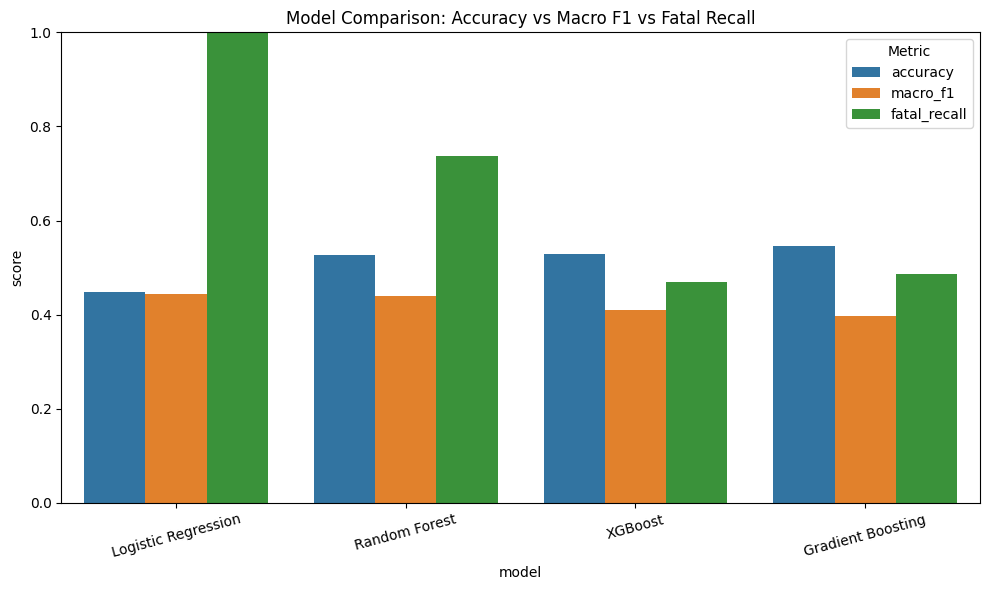

In [8]:
results_melted = results_df.melt(id_vars='model', value_vars=['accuracy','macro_f1','fatal_recall'],
                                  var_name='metric', value_name='score')

plt.figure(figsize=(10,6))
sns.barplot(data=results_melted, x='model', y='score', hue='metric')
plt.title('Model Comparison: Accuracy vs Macro F1 vs Fatal Recall')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

## 6. Pick Best Model & Detailed Evaluation

Best model: Logistic Regression
              precision    recall  f1-score   support

       fatal       0.36      1.00      0.53       597
       major       0.34      0.30      0.32      1198
       minor       0.64      0.38      0.47      2205

    accuracy                           0.45      4000
   macro avg       0.45      0.56      0.44      4000
weighted avg       0.51      0.45      0.44      4000



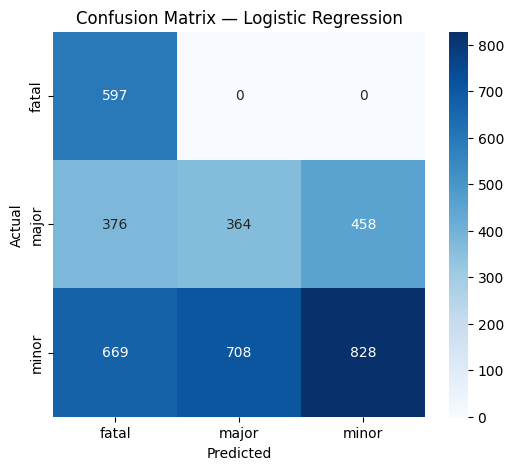

In [9]:
best_model_name = results_df.iloc[0]['model']
best_model = trained_models[best_model_name]
print(f"Best model: {best_model_name}")

y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=target_le.classes_))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_le.classes_, yticklabels=target_le.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

## 7. Feature Importance (Best Model)

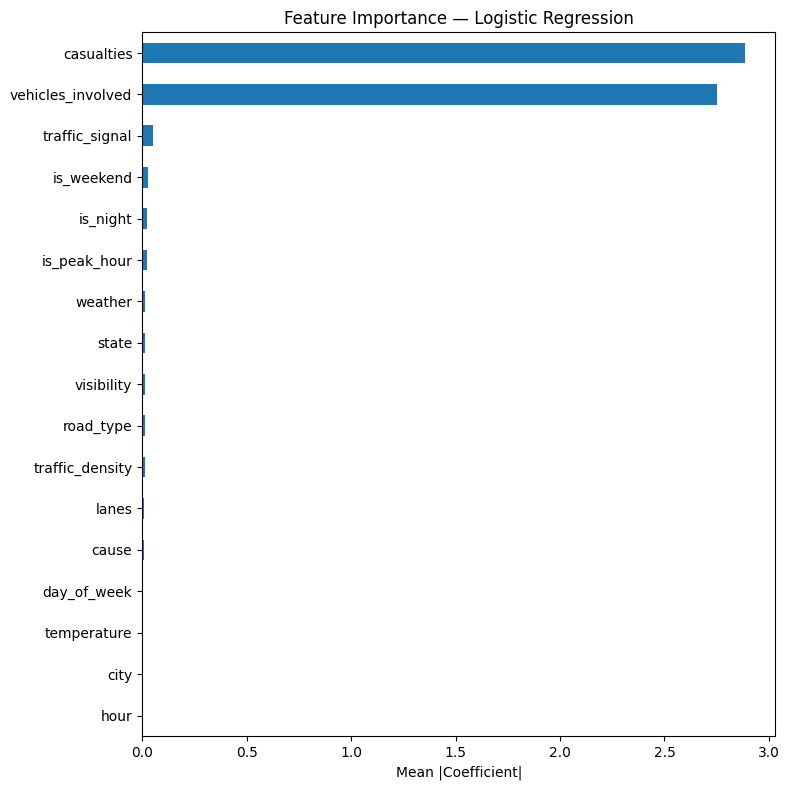

casualties           2.886510
vehicles_involved    2.753446
traffic_signal       0.054073
is_weekend           0.027135
is_night             0.024152
is_peak_hour         0.023043
weather              0.014920
state                0.014705
visibility           0.014123
road_type            0.013996
traffic_density      0.012181
lanes                0.008136
cause                0.006788
day_of_week          0.006672
temperature          0.002229
city                 0.002125
hour                 0.001098
dtype: float64

In [10]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
    ylabel = 'Importance'
else:
    importances = pd.Series(np.abs(best_model.coef_).mean(axis=0), index=features).sort_values(ascending=False)
    ylabel = 'Mean |Coefficient|'

plt.figure(figsize=(8,8))
importances.plot(kind='barh')
plt.title(f'Feature Importance — {best_model_name}')
plt.xlabel(ylabel)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importances

## 8. Save Best Model & Encoders

In [12]:
joblib.dump(best_model, 'data/severity_model.pkl')
joblib.dump(encoders, 'data/label_encoders.pkl')
joblib.dump(target_le, 'data/target_encoder.pkl')

['data/target_encoder.pkl']